<a href="https://colab.research.google.com/github/aliraza0321/neurofive-solutions-ML-internship/blob/main/Task_9_Handling_Imbalanced_%26_Messy_Real_World_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [6]:
# Install the imbalanced-learn library for handling imbalanced datasets
pip install imbalanced-learn

In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, f1_score, precision_score, recall_score
from imblearn.over_sampling import RandomOverSampler, SMOTE
from sklearn.ensemble import RandomForestClassifier
from imblearn.under_sampling import RandomUnderSampler
import seaborn as sns

In [5]:
# Load the credit card fraud dataset from the downloaded path
df=pd.read_csv(f"{path}/creditcard.csv")

In [6]:
# This section generates a synthetic imbalanced dataset for demonstration purposes.
# It creates 10,000 samples with 10 features, where 98% belong to class 0 and 2% to class 1.
# This DataFrame overwrites the previously loaded 'creditcard.csv' data, which is crucial for subsequent steps.
from sklearn.datasets import make_classification

X_raw, y_raw = make_classification(
    n_samples=10000,
    n_features=10,
    weights=[0.98, 0.02], # Specifies the class distribution (98% for class 0, 2% for class 1)
    random_state=42,
)
df = pd.DataFrame(X_raw, columns=[f'feature_{i}' for i in range(10)])
df['Class'] = y_raw

Class Counts:
Class
0    9747
1     253
Name: count, dtype: int64

Fraud Percentage: 2.53%


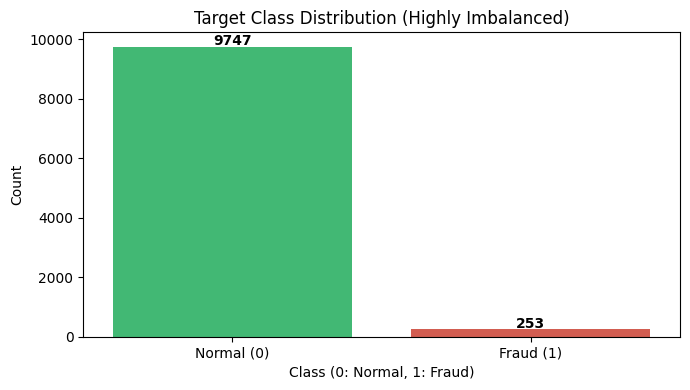

In [7]:
# Counts and Percentage print
class_counts = df['Class'].value_counts()
print("Class Counts:")
print(class_counts)
print(f"\nFraud Percentage: {(class_counts[1] / len(df)) * 100:.2f}%")

#  Bar Chart Plot
plt.figure(figsize=(7, 4))
sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    palette=['#2ecc71', '#e74c3c'],
    hue=class_counts.index,
    legend=False,
)

plt.title('Target Class Distribution (Highly Imbalanced)', fontsize=12)
plt.xlabel('Class (0: Normal, 1: Fraud)')
plt.ylabel('Count')
plt.xticks([0, 1], ['Normal (0)', 'Fraud (1)'])

for i, count in enumerate(class_counts.values):
  plt.text(i, count + 50, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
print(df.head())
print(df.info())

   feature_0  feature_1  feature_2  ...  feature_8  feature_9  Class
0   1.195860   0.357385  -0.665862  ...   0.041266  -0.258298      0
1   0.825314   1.109459  -0.323136  ...   1.150359   0.147744      0
2  -0.906713  -0.593314   0.710714  ...   0.423678   1.251380      0
3   1.200848  -1.306530  -0.496291  ...  -1.624066   0.443553      0
4  -1.204798   0.078464   0.705181  ...   0.495505   0.538133      0

[5 rows x 11 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   feature_0  10000 non-null  float64
 1   feature_1  10000 non-null  float64
 2   feature_2  10000 non-null  float64
 3   feature_3  10000 non-null  float64
 4   feature_4  10000 non-null  float64
 5   feature_5  10000 non-null  float64
 6   feature_6  10000 non-null  float64
 7   feature_7  10000 non-null  float64
 8   feature_8  10000 non-null  float64
 9   feature_9 

In [9]:
# Separate features (X) and target (y)
y=df["Class"]
X=df.drop("Class",axis=1)

In [10]:
# Split the data into training and testing sets
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Initialize and fit the StandardScaler to the training data, then transform both training and testing data
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [11]:
# Initialize a Logistic Regression model
model1=LogisticRegression()
# Train the model on the (imbalanced) training data
model1.fit(x_train,y_train)
# Make predictions on the test set
y_pred1=model1.predict(x_test)

In [12]:
# Initialize a RandomForestClassifier with class weighting to handle imbalance
model2= RandomForestClassifier(class_weight='balanced', random_state=42)
# Train the model on the training data
model2.fit(x_train, y_train)
# Make predictions on the test set
y_pred2 = model2.predict(x_test)

In [16]:
 # Apply SMOTE (Synthetic Minority Over-sampling Technique) to oversample the minority class in the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

# Initialize and train a Logistic Regression model on the SMOTE-resampled data
lr_smote = LogisticRegression(random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)

# Make predictions on the original (un-resampled) test set
y_pred_smote = lr_smote.predict(x_test)

In [17]:
# Metrics calculate karne ke liye helper lists
models = [
    'Baseline (Imbalanced)',
    'Class-Weighted Logistic Regression',
    'SMOTE + Logistic Regression',
]
predictions = [y_pred1, y_pred2, y_pred_smote]

results = []
for model_name, y_pred in zip(models, predictions):
  results.append({
      'Model': model_name,
      'Precision (Class 1)': precision_score(y_test, y_pred, pos_label=1),
      'Recall (Class 1)': recall_score(y_test, y_pred, pos_label=1),
      'F1-Score (Class 1)': f1_score(y_test, y_pred, pos_label=1),
      'Accuracy': (y_pred == y_test).mean(),
  })

df_results = pd.DataFrame(results)
print("=== PERFORMANCE COMPARISON TABLE ===")
display(df_results)

=== PERFORMANCE COMPARISON TABLE ===


,Model,Precision (Class 1),Recall (Class 1),F1-Score (Class 1),Accuracy
0,Baseline (Imbalanced),1.000000,0.075472,0.140351,0.9755
1,Class-Weighted Logistic Regression,0.818182,0.169811,0.281250,0.9770
2,SMOTE + Logistic Regression,0.117470,0.735849,0.202597,0.8465


In [18]:
"""
When 98% of a dataset belongs to the majority class ("Normal")
and only 2% belongs to the minority class ("Fraud"),
a baseline model that naively predicts "No Fraud" for every single transaction
will automatically achieve 98% accuracy. Despite this high accuracy score,
the model is entirely useless in practice because it completely
fails its primary objective: detecting fraudulent activity.


Evaluating an imbalanced model solely on accuracy rewards passive
majority-class bias while hiding critical failures on the minority class.
To measure true real-world utility, we must rely on metrics like Recall (catching positive instances),
Precision (minimizing false alarms), and F1-Score (balancing precision and recall).

"""

'\nWhen 98% of a dataset belongs to the majority class ("Normal") \nand only 2% belongs to the minority class ("Fraud"),\na baseline model that naively predicts "No Fraud" for every single transaction \nwill automatically achieve 98% accuracy. Despite this high accuracy score, \nthe model is entirely useless in practice because it completely\nfails its primary objective: detecting fraudulent activity.\n\n\nEvaluating an imbalanced model solely on accuracy rewards passive\nmajority-class bias while hiding critical failures on the minority class. \nTo measure true real-world utility, we must rely on metrics like Recall (catching positive instances), \nPrecision (minimizing false alarms), and F1-Score (balancing precision and recall).\n\n'